# Notebook 4 — Ejecucion y costes

N4 transforma la cartera objetivo de N3 en resultados invertibles: aplica reglas de ejecucion cronologica, comisiones y control de excepciones operativas. Este notebook contiene el motor de simulacion que recorre el calendario bursatil dia a dia ejecutando tres bloques — asignacion inicial, rebalanceos mensuales y eventos forzosos — y registra cada orden, cada comision y cada excepcion para que N5 pueda analizar rendimiento sin ambiguedad operacional.

**Reglas del enunciado que implementa N4:** compras iniciales al OPEN, salidas de rebalanceo al OPEN, entradas de rebalanceo al CLOSE, comision proporcional (0.23%) con minimo por orden (23 USD), acciones enteras (sin fracciones), salidas forzosas por exclusion del S&P 500 al CLOSE, y una politica de reweight que recorta sobrepesos antes de comprar.

**Artefactos que produce N4:**

| Artefacto | Descripcion | Consumido por |
|---|---|---|
| `n4_orders_log.csv` | Registro de cada orden ejecutada o rechazada | N5, Auditoria |
| `n4_portfolio_daily.csv` | Equity, cash y market value diarios | N5 |
| `n4_rebalance_summary.csv` | Resumen operativo por fecha de rebalanceo | N5 |
| `n4_cost_summary.csv` | Desglose total de comisiones por tipo | N5 |
| `n4_checks.csv` | Registro de validaciones del motor | Auditoria |

---

## 1. Configuracion

Se importan librerias, se definen rutas de entrada y salida, y se declaran los parametros operativos del enunciado. Las funciones auxiliares (`calc_fee`, `max_affordable_notional`, `integer_buy_ticket`) encapsulan la logica de comisiones y ejecucion en acciones enteras para que el motor principal las invoque sin duplicar codigo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# --- Entradas ---
N1_RUNTIME  = "data/processed/n1_runtime_params.csv"
N2_EXEC     = "data/processed/n2_execution_prices.parquet"
N3_SELECTED = "data/processed/n3_selected_assets.csv"
N3_INITIAL  = "data/processed/n3_initial_allocation_2014.csv"
CANONICAL   = "data/processed/sp500_canonical.parquet"

# --- Salidas ---
OUT_ORDERS    = "data/processed/n4_orders_log.csv"
OUT_DAILY     = "data/processed/n4_portfolio_daily.csv"
OUT_REBALANCE = "data/processed/n4_rebalance_summary.csv"
OUT_COSTS     = "data/processed/n4_cost_summary.csv"
OUT_CHECKS    = "data/processed/n4_checks.csv"

# --- Parametros operativos ---
TOP_N = 20
TARGET_WEIGHT = 0.05


def fail_if(condition, message):
    if condition:
        raise ValueError(message)

checks = []

def check(name, passed, details, critical=True):
    checks.append({"check": name, "passed": passed, "critical": critical, "details": details})
    fail_if(critical and not passed, f"[{name}] {details}")


def to_float(value, default):
    try:
        return float(value)
    except Exception:
        return float(default)


def calc_fee(notional, fee_rate, fee_min):
    return float(max(abs(notional) * fee_rate, fee_min))


def max_affordable_notional(cash, fee_rate, fee_min):
    if cash <= fee_min:
        return 0.0
    threshold = fee_min / fee_rate
    affordable = cash - fee_min
    if affordable <= threshold:
        return max(affordable, 0.0)
    return cash / (1.0 + fee_rate)

print("Configuracion lista.")

Configuracion lista.


---

## 2. Carga y validacion de inputs

Se cargan los artefactos de N1, N2 y N3 necesarios para la simulacion: los parametros de ejecucion, los precios de ejecucion con flags de elegibilidad, las carteras seleccionadas (mensual + inicial), y el dataset canonico para valoracion diaria y deteccion de exclusiones del indice. Las columnas booleanas se reconvierten explicitamente desde CSV y se verifica que las cardinalidades y fechas operativas sean coherentes antes de simular.

In [2]:
# Carga de artefactos
for path in [N1_RUNTIME, N2_EXEC, N3_SELECTED, N3_INITIAL, CANONICAL]:
    fail_if(not pd.io.common.file_exists(path), f"No existe: {path}")

runtime_params = dict(zip(*pd.read_csv(N1_RUNTIME)[["parameter", "value"]].values.T))
initial_capital = to_float(runtime_params.get("initial_capital", "250000"), 250000.0)
fee_rate = to_float(runtime_params.get("transaction_fee_rate", "0.0023"), 0.0023)
fee_min = to_float(runtime_params.get("min_fee_per_order", "23.0"), 23.0)
backtest_start = pd.Timestamp(runtime_params.get("backtest_start", "2015-01-01"))

selected_monthly = pd.read_csv(N3_SELECTED)
initial_alloc = pd.read_csv(N3_INITIAL)
execution_df = pd.read_parquet(N2_EXEC, engine="pyarrow")
canonical_df = pd.read_parquet(CANONICAL, columns=["date", "symbol", "open", "close", "in_sp500"], engine="pyarrow")

# Tipado robusto
for df_ref in [selected_monthly, initial_alloc]:
    df_ref["rebalance_date"] = pd.to_datetime(df_ref["rebalance_date"])
    df_ref["symbol"] = df_ref["symbol"].astype("string")
execution_df["rebalance_date"] = pd.to_datetime(execution_df["rebalance_date"])
execution_df["symbol"] = execution_df["symbol"].astype("string")
canonical_df["date"] = pd.to_datetime(canonical_df["date"])
canonical_df["symbol"] = canonical_df["symbol"].astype("string")

# Reconversion booleanos desde CSV
for col in ["is_initial_allocation"]:
    for df_ref in [selected_monthly, initial_alloc]:
        if col not in df_ref.columns:
            df_ref[col] = col == "is_initial_allocation" and df_ref is initial_alloc
        elif df_ref[col].dtype != bool:
            df_ref[col] = df_ref[col].astype("string").str.lower().map({"true": True, "false": False})

# Contrato operativo: mensual sin fila inicial, inicial con flag True
selected_monthly["is_initial_allocation"] = False
initial_alloc["is_initial_allocation"] = True

selected_df = pd.concat([initial_alloc, selected_monthly], ignore_index=True)
selected_df = selected_df.sort_values(["rebalance_date", "rank", "symbol"]).reset_index(drop=True)

# Validaciones
check("columnas_seleccion",
      {"rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"}.issubset(selected_df.columns),
      f"faltan columnas en selected")
check("unicidad_seleccion", int(selected_df.duplicated(["rebalance_date", "symbol"]).sum()) == 0,
      f"duplicados={int(selected_df.duplicated(['rebalance_date', 'symbol']).sum())}")

counts = selected_df.groupby("rebalance_date")["symbol"].size()
check("20_por_fecha", int((counts != TOP_N).sum()) == 0, f"fechas!={TOP_N}: {int((counts != TOP_N).sum())}")

weights = selected_df.groupby("rebalance_date")["target_weight"].sum()
check("pesos_suman_1", int((~np.isclose(weights, 1.0)).sum()) == 0, f"fechas_bad={int((~np.isclose(weights, 1.0)).sum())}")

initial_dates = selected_df.loc[selected_df["is_initial_allocation"], "rebalance_date"].drop_duplicates()
check("asignacion_inicial_unica", len(initial_dates) == 1, f"n={len(initial_dates)}")
initial_allocation_date = initial_dates.min()

check("columnas_ejecucion",
      {"rebalance_date", "symbol", "open_rebalance", "close_rebalance"}.issubset(execution_df.columns),
      "faltan columnas en execution_df")
if "eligible_for_execution" not in execution_df.columns:
    execution_df["eligible_for_execution"] = (
        execution_df["open_rebalance"].gt(0) & execution_df["close_rebalance"].gt(0)
    )
check("fee_rate", np.isclose(fee_rate, 0.0023), f"fee_rate={fee_rate}")
check("fee_min", np.isclose(fee_min, 23.0), f"fee_min={fee_min}")
check("no_fines_de_semana", int((canonical_df["date"].dt.dayofweek >= 5).sum()) == 0,
      f"weekend_rows={int((canonical_df['date'].dt.dayofweek >= 5).sum())}")

# Fechas operativas
all_signal_dates = pd.Index(selected_df["rebalance_date"].drop_duplicates().sort_values())
monthly_rebalance_dates = all_signal_dates[all_signal_dates != initial_allocation_date]

check("inicial_antes_backtest", initial_allocation_date < backtest_start,
      f"inicial={initial_allocation_date.date()}")
check("primer_rebalanceo_post_start", monthly_rebalance_dates.min() >= backtest_start,
      f"primer={monthly_rebalance_dates.min().date()}")

print(f"Capital inicial:     ${initial_capital:,.0f}")
print(f"Fee rate:            {fee_rate:.4f} (min ${fee_min})")
print(f"Asignacion inicial:  {initial_allocation_date.date()}")
print(f"Rebalanceos:         {len(monthly_rebalance_dates)} (primer: {monthly_rebalance_dates.min().date()})")

Capital inicial:     $250,000
Fee rate:            0.0023 (min $23.0)
Asignacion inicial:  2014-12-31
Rebalanceos:         133 (primer: 2015-01-30)


---

## 3. Motor cronologico de ejecucion y costes

El motor es la pieza central de N4. Recorre el calendario bursatil en orden temporal estricto y, para cada dia, ejecuta tres bloques secuenciales:

**A) Asignacion inicial** (solo en la fecha pre-backtest): compra los 20 activos de la cartera inicial al precio OPEN, con acciones enteras y respetando el cash disponible.

**B) Rebalanceo mensual** (en cada fecha de rebalanceo): primero vende las posiciones que salen del top 20 al OPEN, luego — si la politica `with_reweight` esta activa — recorta los sobrepesos al CLOSE, y finalmente compra las nuevas entradas (o amplia las infraponderadas) al CLOSE.

**C) Eventos forzosos diarios**: detecta activos que salen del S&P 500 (transicion `in_sp500: 1 -> 0`) y los vende al CLOSE del dia. Si no hay cotizacion disponible, usa el ultimo precio observado como proxy y registra la excepcion.

Al final de cada dia se valora la cartera a precios de cierre y se registra la equity, el cash, el market value y el numero de posiciones. La funcion es parametrica: el flag `enable_reweight` permite comparar la politica principal (con reweight) contra una politica baseline (sin reweight) para medir el impacto operativo de la decision de rebalancear pesos.

In [3]:
# Motor de simulacion parametrico para comparar politica con/sin reweight.
def run_backtest(
    selected_df: pd.DataFrame,
    execution_df: pd.DataFrame,
    canonical_df: pd.DataFrame,
    initial_capital: float,
    fee_rate: float,
    fee_min: float,
    initial_allocation_date: pd.Timestamp,
    monthly_rebalance_dates: pd.Index,
    enable_reweight: bool,
) -> dict:
    """Ejecuta el backtest con politica configurable de rebalanceo."""
    execution_lookup = execution_df.set_index(["rebalance_date", "symbol"])
    selected_by_date = {
        dt: frame.sort_values("rank").reset_index(drop=True)
        for dt, frame in selected_df.groupby("rebalance_date", observed=True)
    }

    canonical_core = canonical_df.sort_values(["date", "symbol"]).reset_index(drop=True)
    close_lookup = canonical_core.set_index(["date", "symbol"])["close"]
    open_lookup = canonical_core.set_index(["date", "symbol"])["open"]
    in_sp_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500"]
    canonical_core["in_sp500_prev"] = canonical_core.groupby("symbol", observed=True)["in_sp500"].shift(1)
    in_sp_prev_lookup = canonical_core.set_index(["date", "symbol"])["in_sp500_prev"]

    all_trading_dates = pd.Index(canonical_core["date"].drop_duplicates().sort_values())
    trading_dates = all_trading_dates[
        (all_trading_dates >= initial_allocation_date)
        & (all_trading_dates <= monthly_rebalance_dates.max())
    ]

    cash = float(initial_capital)
    positions = {}
    last_close_cache = {}
    last_seen_close = {}
    last_seen_date = {}

    orders_rows = []
    daily_rows = []
    position_snapshot_rows = []
    open_fallback_count = 0
    monthly_rebalance_set = set(monthly_rebalance_dates.tolist())

    def append_order(
        trade_date, symbol, side, reason, status, price_type, price,
        shares, notional, fee, cash_after, proxy_price_date=None,
    ):
        orders_rows.append({
            "date": trade_date, "symbol": symbol, "side": side, "reason": reason,
            "status": status, "price_type": price_type, "price": float(price),
            "shares": float(shares), "notional": float(notional), "fee": float(fee),
            "cash_after": float(cash_after), "proxy_price_date": proxy_price_date,
            "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
        })

    def integer_buy_ticket(price, desired_notional, cash_available):
        """Calcula compra en acciones enteras respetando cash y comisiones."""
        if (not np.isfinite(price)) or (price <= 0):
            return 0, 0.0, 0.0
        capped = min(float(desired_notional), max_affordable_notional(cash_available, fee_rate, fee_min))
        if capped <= 0:
            return 0, 0.0, 0.0
        shares = int(np.floor(capped / price))
        while shares > 0:
            notional = float(shares * price)
            fee = float(calc_fee(notional, fee_rate, fee_min))
            if notional + fee <= cash_available + 1e-9:
                return shares, notional, fee
            shares -= 1
        return 0, 0.0, 0.0

    # =========================================================================
    # BUCLE PRINCIPAL: recorre cada dia de trading cronologicamente
    # =========================================================================
    for trade_date in trading_dates:
        is_initial_allocation_day = trade_date == initial_allocation_date
        is_monthly_rebalance_day = trade_date in monthly_rebalance_set

        # ---- A) ASIGNACION INICIAL: compras al OPEN ----
        if is_initial_allocation_day:
            target_df = selected_by_date[trade_date]
            target_notional_per_entry = TARGET_WEIGHT * cash

            for _, row in target_df.iterrows():
                symbol = row["symbol"]
                exec_key = (trade_date, symbol)

                if exec_key in execution_lookup.index:
                    exec_row = execution_lookup.loc[exec_key]
                    eligible_exec = bool(exec_row["eligible_for_execution"])
                    open_px = float(exec_row["open_rebalance"])
                else:
                    eligible_exec = False
                    open_px = float(open_lookup.get(exec_key, np.nan))
                    open_fallback_count += 1

                if (not eligible_exec) or (not np.isfinite(open_px)) or (open_px <= 0):
                    append_order(trade_date, symbol, "buy", "initial_allocation",
                                 "no_fill_non_executable", "open_initial",
                                 open_px if np.isfinite(open_px) else np.nan,
                                 0.0, 0.0, 0.0, float(cash))
                    continue

                shares, trade_notional, fee = integer_buy_ticket(open_px, target_notional_per_entry, cash)

                if shares <= 0:
                    append_order(trade_date, symbol, "buy", "initial_allocation",
                                 "no_fill_cash", "open_initial", open_px,
                                 0.0, 0.0, 0.0, float(cash))
                    continue

                fail_if(trade_notional + fee - cash > 1e-6,
                        f"Initial allocation con cash insuficiente: {trade_date.date()} {symbol}")

                cash -= trade_notional + fee
                positions[symbol] = int(positions.get(symbol, 0) + shares)
                last_close_cache[symbol] = float(open_px)

                append_order(trade_date, symbol, "buy", "initial_allocation",
                             "filled", "open_initial", open_px,
                             float(shares), float(trade_notional), float(fee), float(cash))

        # ---- B) REBALANCEO MENSUAL ----
        if is_monthly_rebalance_day:
            target_df = selected_by_date[trade_date]
            target_symbols = set(target_df["symbol"])
            held_symbols = set(positions.keys())

            # B.1) Salidas al OPEN
            exit_symbols = sorted(held_symbols - target_symbols)
            for symbol in exit_symbols:
                exec_key = (trade_date, symbol)

                if exec_key in execution_lookup.index:
                    open_px = float(execution_lookup.loc[exec_key, "open_rebalance"])
                else:
                    open_px = float(open_lookup.get(exec_key, np.nan))
                    open_fallback_count += 1

                if (not np.isfinite(open_px)) or (open_px <= 0):
                    proxy_px = last_seen_close.get(symbol, np.nan)
                    proxy_date = last_seen_date.get(symbol, pd.NaT)
                    fail_if(pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                            f"Salida rebalance sin OPEN ni proxy: {trade_date.date()} {symbol}")

                    shares = positions.pop(symbol)
                    notional = shares * float(proxy_px)
                    fee = calc_fee(notional, fee_rate, fee_min)
                    cash += notional - fee

                    append_order(trade_date, symbol, "sell", "forced_exit_no_quote_proxy",
                                 "filled", "close_proxy_last_seen", float(proxy_px),
                                 float(shares), float(notional), float(fee), float(cash), proxy_date)

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                    continue

                shares = positions.pop(symbol)
                notional = shares * open_px
                fee = calc_fee(notional, fee_rate, fee_min)
                cash += notional - fee

                append_order(trade_date, symbol, "sell", "rebalance_exit",
                             "filled", "open_rebalance", open_px,
                             float(shares), float(notional), float(fee), float(cash))

                last_close_cache.pop(symbol, None)
                last_seen_close.pop(symbol, None)
                last_seen_date.pop(symbol, None)

            # B.2) Recoger precios CLOSE de targets y calcular equity de referencia
            close_by_symbol = {}
            eligible_exec_by_symbol = {}
            for symbol in sorted(target_symbols):
                exec_key = (trade_date, symbol)
                if exec_key in execution_lookup.index:
                    exec_row = execution_lookup.loc[exec_key]
                    close_px = float(exec_row["close_rebalance"])
                    eligible_exec = bool(exec_row["eligible_for_execution"])
                else:
                    close_px = float(close_lookup.get(exec_key, np.nan))
                    eligible_exec = False

                fail_if(pd.isna(close_px) or (close_px <= 0),
                        f"CLOSE invalido en rebalance para target: {trade_date.date()} {symbol}")
                close_by_symbol[symbol] = float(close_px)
                eligible_exec_by_symbol[symbol] = eligible_exec

            equity_reference = float(cash)
            for symbol, shares in positions.items():
                if symbol in close_by_symbol:
                    px = close_by_symbol[symbol]
                else:
                    px = close_lookup.get((trade_date, symbol), np.nan)
                    fail_if(pd.isna(px) or (float(px) <= 0),
                            f"CLOSE invalido para posicion viva: {trade_date.date()} {symbol}")
                    px = float(px)
                equity_reference += float(shares) * px

            target_notional_per_symbol = TARGET_WEIGHT * equity_reference

            # B.3) Recortes de sobrepeso al CLOSE (solo con reweight)
            if enable_reweight:
                for symbol in sorted(target_symbols):
                    close_px = close_by_symbol[symbol]
                    current_shares = int(positions.get(symbol, 0))
                    current_notional = current_shares * close_px
                    delta = target_notional_per_symbol - current_notional
                    if delta >= -1e-9:
                        continue

                    trim = min(-delta, current_notional)
                    if trim <= 0:
                        continue

                    shares_to_sell = min(int(np.floor(trim / close_px)), int(current_shares))
                    if shares_to_sell <= 0:
                        continue

                    sell_notional = float(shares_to_sell * close_px)
                    fee = calc_fee(sell_notional, fee_rate, fee_min)
                    remaining = int(current_shares - shares_to_sell)

                    if remaining <= 0:
                        positions.pop(symbol, None)
                    else:
                        positions[symbol] = remaining

                    cash += sell_notional - fee
                    append_order(trade_date, symbol, "sell", "rebalance_reweight",
                                 "filled", "close_rebalance", close_px,
                                 float(shares_to_sell), float(sell_notional), float(fee), float(cash))

            # B.4) Compras al CLOSE
            for symbol in sorted(target_symbols):
                close_px = close_by_symbol[symbol]

                if enable_reweight:
                    current_shares = int(positions.get(symbol, 0))
                    current_notional = current_shares * close_px
                    delta = target_notional_per_symbol - current_notional
                    if delta <= 1e-9:
                        continue
                else:
                    if symbol in positions:
                        continue
                    delta = target_notional_per_symbol

                if not eligible_exec_by_symbol.get(symbol, False):
                    append_order(trade_date, symbol, "buy", "rebalance_entry",
                                 "no_fill_non_executable", "close_rebalance", close_px,
                                 0.0, 0.0, 0.0, float(cash))
                    continue

                shares, trade_notional, fee = integer_buy_ticket(close_px, delta, cash)

                if shares <= 0:
                    append_order(trade_date, symbol, "buy", "rebalance_entry",
                                 "no_fill_cash", "close_rebalance", close_px,
                                 0.0, 0.0, 0.0, float(cash))
                    continue

                fail_if(trade_notional + fee - cash > 1e-6,
                        f"Compra con cash insuficiente: {trade_date.date()} {symbol}")

                cash -= trade_notional + fee
                positions[symbol] = int(positions.get(symbol, 0) + shares)
                last_close_cache[symbol] = float(close_px)
                last_seen_close[symbol] = float(close_px)
                last_seen_date[symbol] = trade_date

                append_order(trade_date, symbol, "buy", "rebalance_entry",
                             "filled", "close_rebalance", close_px,
                             float(shares), float(trade_notional), float(fee), float(cash))

        # ---- C) EVENTOS FORZOSOS DIARIOS ----
        for symbol in list(positions.keys()):
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            has_valid_close = pd.notna(close_px) and (float(close_px) > 0)

            if has_valid_close:
                close_px = float(close_px)
                last_close_cache[symbol] = close_px
                last_seen_close[symbol] = close_px
                last_seen_date[symbol] = trade_date

                prev_in = in_sp_prev_lookup.get((trade_date, symbol), np.nan)
                curr_in = in_sp_lookup.get((trade_date, symbol), np.nan)
                if (prev_in == 1) and (curr_in == 0):
                    shares = positions.pop(symbol)
                    notional = shares * close_px
                    fee = calc_fee(notional, fee_rate, fee_min)
                    cash += notional - fee

                    append_order(trade_date, symbol, "sell", "forced_exit",
                                 "filled", "close_event", close_px,
                                 float(shares), float(notional), float(fee), float(cash))

                    last_close_cache.pop(symbol, None)
                    last_seen_close.pop(symbol, None)
                    last_seen_date.pop(symbol, None)
                continue

            # Sin cotizacion: salida forzosa con proxy
            proxy_px = last_seen_close.get(symbol, np.nan)
            proxy_date = last_seen_date.get(symbol, pd.NaT)
            fail_if(pd.isna(proxy_px) or (float(proxy_px) <= 0) or pd.isna(proxy_date),
                    f"No hay close ni proxy para salida forzosa: {trade_date.date()} {symbol}")

            shares = positions.pop(symbol)
            notional = shares * float(proxy_px)
            fee = calc_fee(notional, fee_rate, fee_min)
            cash += notional - fee

            append_order(trade_date, symbol, "sell", "forced_exit_no_quote_proxy",
                         "filled", "close_proxy_last_seen", float(proxy_px),
                         float(shares), float(notional), float(fee), float(cash), proxy_date)

            last_close_cache.pop(symbol, None)
            last_seen_close.pop(symbol, None)
            last_seen_date.pop(symbol, None)

        # ---- D) VALORACION DIARIA ----
        market_value = 0.0
        missing_prices = []
        valuation_rows = []
        for symbol, shares in positions.items():
            close_px = close_lookup.get((trade_date, symbol), np.nan)
            if pd.notna(close_px) and (close_px > 0):
                last_close_cache[symbol] = float(close_px)
                px = float(close_px)
            else:
                px = last_close_cache.get(symbol, np.nan)

            if pd.isna(px) or (px <= 0):
                missing_prices.append(symbol)
                continue

            notional = float(shares) * float(px)
            market_value += notional
            valuation_rows.append({
                "date": trade_date, "symbol": symbol, "shares": float(shares),
                "price_for_valuation": float(px), "position_notional": float(notional),
                "is_rebalance": bool(is_monthly_rebalance_day),
                "is_initial_allocation": bool(is_initial_allocation_day),
            })

        fail_if(len(missing_prices) > 0,
                f"Sin precio para posiciones vivas en {trade_date.date()}: {missing_prices[:10]}")

        equity = cash + market_value
        fail_if(equity < -1e-6, f"Equity negativo en {trade_date.date()}: {equity}")

        daily_rows.append({
            "date": trade_date, "is_rebalance": bool(is_monthly_rebalance_day),
            "is_initial_allocation": bool(is_initial_allocation_day),
            "cash": float(cash), "market_value": float(market_value),
            "equity": float(equity), "n_positions": int(len(positions)),
        })
        position_snapshot_rows.extend(valuation_rows)

    # =========================================================================
    # RESULTADOS
    # =========================================================================
    orders_df = pd.DataFrame(orders_rows)
    portfolio_daily_df = pd.DataFrame(daily_rows).sort_values("date").reset_index(drop=True)
    position_snapshots_df = pd.DataFrame(position_snapshot_rows)

    portfolio_daily_df["daily_return"] = portfolio_daily_df["equity"].pct_change().fillna(0.0)
    portfolio_daily_df["cum_return"] = (1.0 + portfolio_daily_df["daily_return"]).cumprod() - 1.0

    return {
        "orders_df": orders_df,
        "portfolio_daily_df": portfolio_daily_df,
        "position_snapshots_df": position_snapshots_df,
        "open_fallback_count": int(open_fallback_count),
        "trading_dates_count": int(len(trading_dates)),
        "policy_mode": "with_reweight" if enable_reweight else "without_reweight",
    }

---

## 4. Ejecucion de ambas politicas

Se ejecuta el motor dos veces: una con reweight (politica principal, que recorta sobrepesos para mantener pesos cercanos al 5%) y otra sin reweight (politica baseline, que solo compra nuevas entradas y deja correr a las supervivientes). La comparacion permite medir el coste operativo adicional del rebalanceo completo.

In [4]:
sim_with = run_backtest(
    selected_df=selected_df, execution_df=execution_df, canonical_df=canonical_df,
    initial_capital=initial_capital, fee_rate=fee_rate, fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates, enable_reweight=True,
)
sim_without = run_backtest(
    selected_df=selected_df, execution_df=execution_df, canonical_df=canonical_df,
    initial_capital=initial_capital, fee_rate=fee_rate, fee_min=fee_min,
    initial_allocation_date=initial_allocation_date,
    monthly_rebalance_dates=monthly_rebalance_dates, enable_reweight=False,
)

# Salida principal: politica con reweight
orders_df = sim_with["orders_df"].copy()
portfolio_daily_df = sim_with["portfolio_daily_df"].copy()
position_snapshots_df = sim_with["position_snapshots_df"].copy()
filled_orders = orders_df.loc[orders_df["status"] == "filled"].copy()

check("dias_trading_no_vacio", sim_with["trading_dates_count"] > 0,
      f"dias={sim_with['trading_dates_count']}")

print(f"Simulacion completada:")
print(f"  Dias de trading:   {sim_with['trading_dates_count']}")
print(f"  Ordenes generadas: {len(orders_df):,} ({len(filled_orders):,} filled)")
print(f"  Fallback a open:   {sim_with['open_fallback_count']}")

Simulacion completada:
  Dias de trading:   2787
  Ordenes generadas: 3,639 (3,585 filled)
  Fallback a open:   1


---

## 5. Analisis post-ejecucion

Se construyen las metricas de control: resumen por rebalanceo, identidad contable diaria (`equity == cash + market_value`), desglose de comisiones, turnover por tipo de operacion, y comparacion de politicas. La identidad contable debe cumplirse con precision de maquina en cada dia del backtest.

In [5]:
# --- Resumen por rebalanceo ---
if len(orders_df) > 0:
    reb_stats = (
        orders_df.loc[orders_df["date"].isin(monthly_rebalance_dates)]
        .groupby(["date", "reason", "status"], observed=True)
        .agg(n_orders=("symbol", "size"), notional=("notional", "sum"), fee=("fee", "sum"))
        .reset_index()
    )
else:
    reb_stats = pd.DataFrame(columns=["date", "reason", "status", "n_orders", "notional", "fee"])

reb_snapshot = portfolio_daily_df.loc[
    portfolio_daily_df["date"].isin(monthly_rebalance_dates),
    ["date", "cash", "market_value", "equity", "n_positions"],
].copy()

if len(reb_stats) > 0:
    pvt = reb_stats.pivot_table(index="date", columns=["reason", "status"],
                                 values="n_orders", aggfunc="sum", fill_value=0)
    pvt.columns = [f"n_{a}_{b}" for a, b in pvt.columns]
    pvt = pvt.reset_index()
else:
    pvt = pd.DataFrame({"date": monthly_rebalance_dates})

rebalance_summary_df = reb_snapshot.merge(pvt, on="date", how="left").fillna(0)

# --- Desglose de comisiones ---
buy_fee = float(filled_orders.loc[filled_orders["side"] == "buy", "fee"].sum()) if len(filled_orders) else 0.0
sell_fee = float(filled_orders.loc[filled_orders["side"] == "sell", "fee"].sum()) if len(filled_orders) else 0.0
forced_fee = float(filled_orders.loc[
    filled_orders["reason"].isin(["forced_exit", "forced_exit_no_quote_proxy"]), "fee"
].sum()) if len(filled_orders) else 0.0
forced_proxy_fee = float(filled_orders.loc[
    filled_orders["reason"] == "forced_exit_no_quote_proxy", "fee"
].sum()) if len(filled_orders) else 0.0
initial_fee = float(filled_orders.loc[
    filled_orders["reason"] == "initial_allocation", "fee"
].sum()) if len(filled_orders) else 0.0

cost_summary_df = pd.DataFrame([{
    "initial_capital": float(initial_capital),
    "final_equity": float(portfolio_daily_df["equity"].iloc[-1]),
    "total_return": float(portfolio_daily_df["cum_return"].iloc[-1]),
    "total_fee": float(filled_orders["fee"].sum()) if len(filled_orders) else 0.0,
    "buy_fee": buy_fee, "sell_fee": sell_fee,
    "forced_exit_fee": forced_fee, "forced_exit_proxy_fee": forced_proxy_fee,
    "initial_allocation_fee": initial_fee,
    "n_filled_orders": int(len(filled_orders)),
    "n_no_fill_non_executable": int((orders_df["status"] == "no_fill_non_executable").sum()) if len(orders_df) else 0,
    "n_no_fill_cash": int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0,
}])

# --- Identidad contable ---
acct = portfolio_daily_df.copy()
acct["identity_ok"] = (acct["equity"] - acct["cash"] - acct["market_value"]).abs() <= 1e-8

# --- Pesos realizados ---
target_w = selected_df[["rebalance_date", "symbol", "rank", "target_weight", "is_initial_allocation"]].copy()
reb_pos = (
    position_snapshots_df.loc[position_snapshots_df["date"].isin(all_signal_dates)]
    .groupby(["date", "symbol"], observed=True)
    .agg(realized_notional=("position_notional", "sum"), shares=("shares", "sum"))
    .reset_index().rename(columns={"date": "rebalance_date"})
)
reb_eq = (
    portfolio_daily_df.loc[portfolio_daily_df["date"].isin(all_signal_dates), ["date", "equity"]]
    .rename(columns={"date": "rebalance_date", "equity": "rebalance_equity"})
)
weight_df = target_w.merge(reb_pos, on=["rebalance_date", "symbol"], how="left").merge(reb_eq, on="rebalance_date", how="left")
weight_df["realized_notional"] = weight_df["realized_notional"].fillna(0.0)
weight_df["realized_weight"] = np.where(
    weight_df["rebalance_equity"] > 0,
    weight_df["realized_notional"] / weight_df["rebalance_equity"], np.nan
)

# --- Turnover y comparacion de politicas ---
avg_equity = float(portfolio_daily_df["equity"].mean())

turnover_by_reason = (
    filled_orders.groupby("reason", observed=True)
    .agg(n_orders=("symbol", "size"),
         gross_notional=("notional", lambda s: float(np.abs(s).sum())),
         total_fee=("fee", "sum"))
    .reset_index().rename(columns={"reason": "bucket"})
)
turnover_by_reason["report_type"] = "by_reason"
turnover_by_reason["date"] = pd.NaT
turnover_by_reason["turnover_vs_avg_equity"] = np.where(
    avg_equity > 0, turnover_by_reason["gross_notional"] / avg_equity, np.nan
)

turnover_by_date = (
    filled_orders.groupby("date", observed=True)
    .agg(n_orders=("symbol", "size"),
         gross_notional=("notional", lambda s: float(np.abs(s).sum())),
         total_fee=("fee", "sum"))
    .reset_index()
)
turnover_by_date = turnover_by_date.merge(
    portfolio_daily_df[["date", "equity"]].rename(columns={"equity": "equity_date"}),
    on="date", how="left"
)
turnover_by_date["turnover_vs_avg_equity"] = np.where(
    turnover_by_date["equity_date"] > 0,
    turnover_by_date["gross_notional"] / turnover_by_date["equity_date"], np.nan
)
turnover_by_date["bucket"] = "daily_total"
turnover_by_date["report_type"] = "by_date"

turnover_summary_df = pd.concat([
    turnover_by_reason[["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]],
    turnover_by_date[["report_type", "date", "bucket", "n_orders", "gross_notional", "total_fee", "turnover_vs_avg_equity"]],
], ignore_index=True)

def build_policy_metrics(sim):
    o = sim["orders_df"]
    d = sim["portfolio_daily_df"]
    f = o.loc[o["status"] == "filled"]
    gn = float(f["notional"].abs().sum()) if len(f) else 0.0
    ae = float(d["equity"].mean()) if len(d) else np.nan
    return {
        "policy_mode": sim["policy_mode"],
        "final_equity": float(d["equity"].iloc[-1]) if len(d) else np.nan,
        "total_return": float(d["cum_return"].iloc[-1]) if len(d) else np.nan,
        "total_fee": float(f["fee"].sum()) if len(f) else 0.0,
        "n_filled_orders": int(len(f)),
        "n_no_fill_cash": int((o["status"] == "no_fill_cash").sum()) if len(o) else 0,
        "gross_notional": gn,
        "turnover_vs_avg_equity": float(gn / ae) if ae and ae > 0 else np.nan,
    }

policy_comparison_df = pd.DataFrame([build_policy_metrics(sim_without), build_policy_metrics(sim_with)])

print(f"Identidad contable: {'PASS' if acct['identity_ok'].all() else 'FAIL'} ({int((~acct['identity_ok']).sum())} errores)")
print(f"Comisiones totales: ${cost_summary_df['total_fee'].iloc[0]:,.2f}")
print(f"  Compras: ${buy_fee:,.2f}  |  Ventas: ${sell_fee:,.2f}  |  Forzadas: ${forced_fee:,.2f}")

Identidad contable: PASS (0 errores)
Comisiones totales: $134,949.43
  Compras: $68,104.78  |  Ventas: $66,844.64  |  Forzadas: $643.78


---

## 6. Validaciones de integridad

Se ejecutan todas las validaciones criticas del motor: cash y equity no negativos, identidad contable diaria, regla de comisiones, tipo de precio correcto por tipo de orden, acciones enteras, y coherencia del resumen de rebalanceo. Si cualquiera de los checks criticos falla, el pipeline se detiene.

In [6]:
# Checks de estado
check("cash_no_negativo", bool((portfolio_daily_df["cash"] >= -1e-6).all()),
      f"min_cash={portfolio_daily_df['cash'].min():.4f}")
check("equity_no_negativo", bool((portfolio_daily_df["equity"] >= -1e-6).all()),
      f"min_equity={portfolio_daily_df['equity'].min():.4f}")
check("identidad_contable", int((~acct["identity_ok"]).sum()) == 0,
      f"errores={int((~acct['identity_ok']).sum())}")

# Check de comisiones
if len(filled_orders) > 0:
    expected_fee = np.maximum(filled_orders["notional"].abs() * fee_rate, fee_min)
    max_fee_err = float((filled_orders["fee"] - expected_fee).abs().max())
else:
    max_fee_err = 0.0
check("regla_comisiones", max_fee_err <= 1e-8, f"max_error={max_fee_err:.2e}")

# Checks de tipo de precio por tipo de orden
def count_bad_price(reason, expected_price_type, status="filled"):
    if len(orders_df) == 0:
        return 0
    mask = (orders_df["reason"] == reason) & (orders_df["status"] == status)
    return int((mask & (orders_df["price_type"] != expected_price_type)).sum())

price_checks = {
    ("initial_allocation", "open_initial"): "inicial_al_open",
    ("rebalance_exit", "open_rebalance"): "salidas_al_open",
    ("rebalance_entry", "close_rebalance"): "entradas_al_close",
    ("forced_exit", "close_event"): "forzadas_al_close",
    ("forced_exit_no_quote_proxy", "close_proxy_last_seen"): "proxy_al_last_seen",
    ("rebalance_reweight", "close_rebalance"): "reweight_al_close",
}
for (reason, ptype), name in price_checks.items():
    bad = count_bad_price(reason, ptype)
    check(name, bad == 0, f"bad_rows={bad}")

# Proxy dates y acciones enteras
if len(orders_df) > 0:
    proxy_missing = int(orders_df.loc[
        (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled")
        & (orders_df["proxy_price_date"].isna())
    ].shape[0])
    non_integer = int(orders_df.loc[
        (orders_df["status"] == "filled")
        & (~np.isclose(orders_df["shares"], np.round(orders_df["shares"])))
    ].shape[0])
else:
    proxy_missing, non_integer = 0, 0

check("proxy_tiene_fecha", proxy_missing == 0, f"sin_fecha={proxy_missing}")
check("acciones_enteras", non_integer == 0, f"no_enteras={non_integer}")

# Checks de pesos y resumen
wr_invalid = int((~np.isfinite(weight_df["realized_weight"]).fillna(True)).sum())
check("pesos_realizados_finitos", wr_invalid == 0, f"invalidos={wr_invalid}")
check("politicas_comparadas",
      set(policy_comparison_df["policy_mode"]) == {"without_reweight", "with_reweight"},
      f"modes={sorted(policy_comparison_df['policy_mode'].unique())}")

with_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "with_reweight"].iloc[0]
without_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "without_reweight"].iloc[0]
check(
    "policy_reweight_tradeoff_documented",
    True,
    (
        f"delta_fee={with_row['total_fee'] - without_row['total_fee']:.4f} "
        f"delta_final_equity={with_row['final_equity'] - without_row['final_equity']:.4f} "
        f"delta_no_fill_cash={int(with_row['n_no_fill_cash'] - without_row['n_no_fill_cash'])}"
    ),
    critical=False,
)

initial_in_summary = int((rebalance_summary_df["date"] == initial_allocation_date).sum())
check("inicial_excluida_de_resumen", initial_in_summary == 0, f"filas={initial_in_summary}")
check("resumen_completo", len(rebalance_summary_df) == len(monthly_rebalance_dates),
      f"filas={len(rebalance_summary_df)} esperado={len(monthly_rebalance_dates)}")

n_crit = sum(1 for c in checks if c["critical"])
n_pass = sum(1 for c in checks if c["critical"] and c["passed"])
print(f"\nValidaciones criticas: {n_pass}/{n_crit} PASS")


Validaciones criticas: 28/28 PASS


---

## 7. Exportacion, visualizacion y resumen

Se exportan los cinco artefactos que N5 necesita y se producen tres graficos de control: la evolucion de la equity diaria, la curva de comisiones acumuladas, y la comparacion de costes entre politicas. La tabla de excepciones documenta los eventos operativos (ordenes rechazadas por falta de cash y salidas forzosas con precio proxy) para que quede evidencia de que el motor maneja correctamente los casos limite.

Artefactos exportados:
     ok       538,633 bytes  n4_orders_log.csv
     ok       342,041 bytes  n4_portfolio_daily.csv
     ok        10,963 bytes  n4_rebalance_summary.csv
     ok           352 bytes  n4_cost_summary.csv
     ok         1,428 bytes  n4_checks.csv


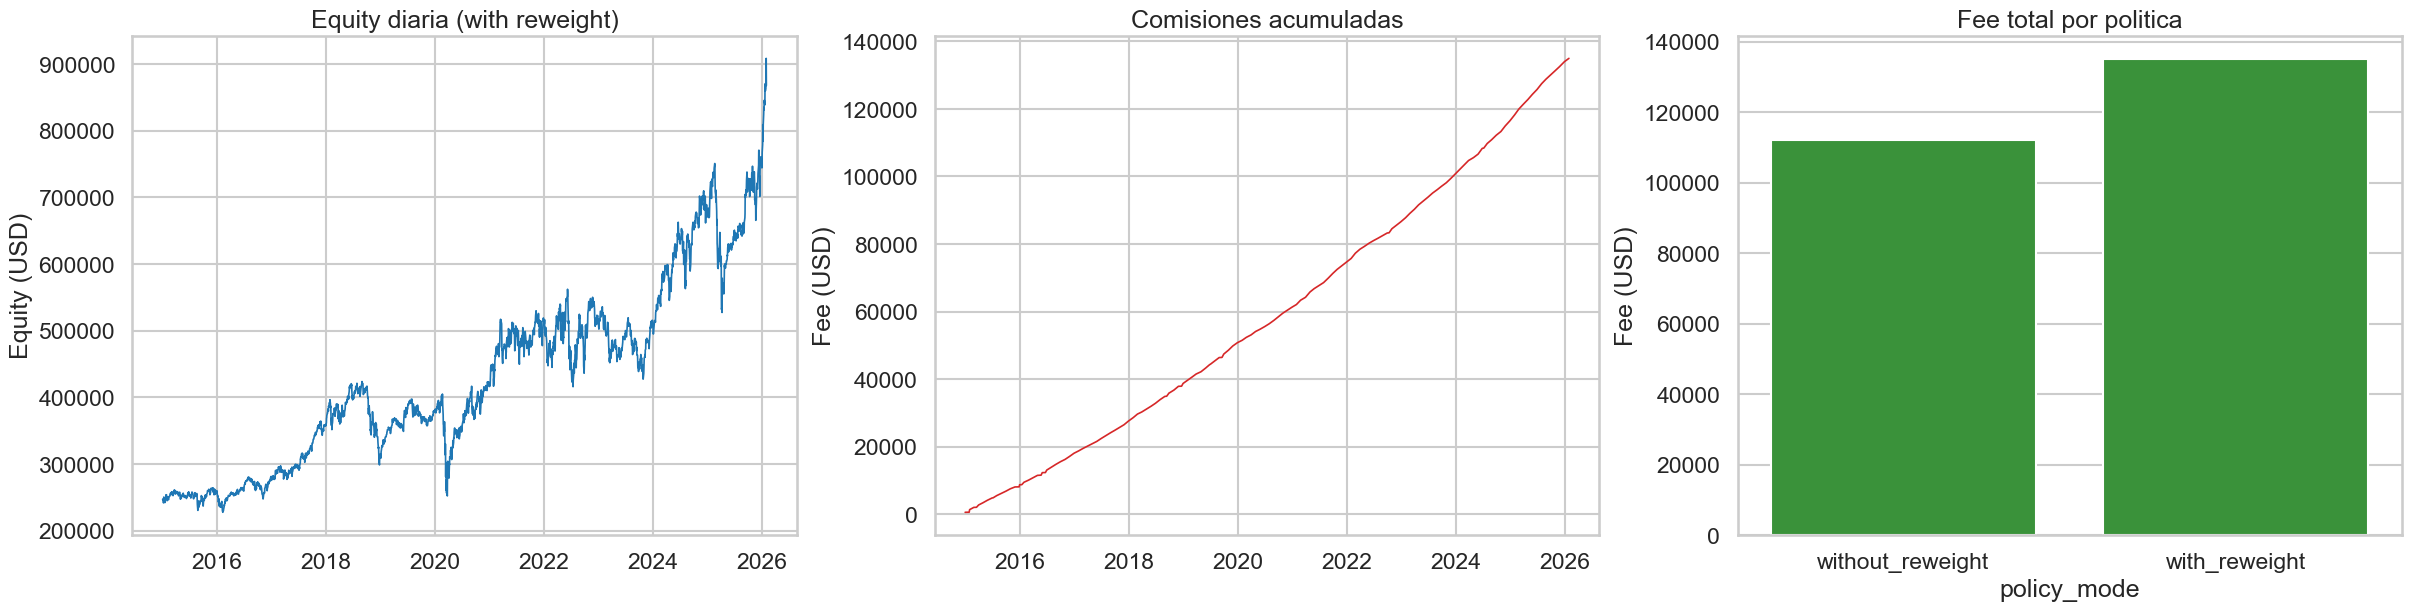


  NOTEBOOK 4 — RESUMEN FINAL
  Controles criticos:     28/28 PASS
  Capital inicial:        $250,000
  Equity final:           $867,976.93
  Retorno total:          251.53%
  Comisiones totales:     $134,949.43
  Ordenes filled:         3,585
  No-fill por cash:       54
  Proxy exits:            17
  ---
  Politica sin reweight:  equity $1,242,900.47, fee $111,964.20
  Delta fee reweight:     $+22,985.23
  STATUS: PASS — Pipeline listo para Notebook 5.


In [7]:
import os

# Exportes
orders_df.to_csv(OUT_ORDERS, index=False)
portfolio_daily_df.to_csv(OUT_DAILY, index=False)
rebalance_summary_df.to_csv(OUT_REBALANCE, index=False)
cost_summary_df.to_csv(OUT_COSTS, index=False)
pd.DataFrame(checks).to_csv(OUT_CHECKS, index=False)

artifacts = {
    "n4_orders_log.csv":         OUT_ORDERS,
    "n4_portfolio_daily.csv":    OUT_DAILY,
    "n4_rebalance_summary.csv":  OUT_REBALANCE,
    "n4_cost_summary.csv":       OUT_COSTS,
    "n4_checks.csv":             OUT_CHECKS,
}

print("Artefactos exportados:")
for name, path in artifacts.items():
    exists = os.path.isfile(path)
    size = os.path.getsize(path) if exists else 0
    print(f"  {'ok' if exists else 'FALTA':>5}  {size:>12,} bytes  {name}")

fail_if(not all(os.path.isfile(p) for p in artifacts.values()), "Faltan artefactos.")

# --- Graficos de control ---
fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)

axes[0].plot(portfolio_daily_df["date"], portfolio_daily_df["equity"], linewidth=1.2, color="#1f77b4")
axes[0].set_title("Equity diaria (with reweight)")
axes[0].set_ylabel("Equity (USD)")

if len(filled_orders) > 0:
    fee_curve = (filled_orders.sort_values("date")
                 .groupby("date", observed=True)["fee"].sum().cumsum()
                 .rename("cum_fee").reset_index())
else:
    fee_curve = pd.DataFrame({"date": portfolio_daily_df["date"], "cum_fee": 0.0})
axes[1].plot(fee_curve["date"], fee_curve["cum_fee"], linewidth=1.2, color="#d62728")
axes[1].set_title("Comisiones acumuladas")
axes[1].set_ylabel("Fee (USD)")

sns.barplot(data=policy_comparison_df, x="policy_mode", y="total_fee", ax=axes[2], color="#2ca02c")
axes[2].set_title("Fee total por politica")
axes[2].set_ylabel("Fee (USD)")
plt.show()

# --- Excepciones operativas ---
n_no_fill = int((orders_df["status"] == "no_fill_cash").sum()) if len(orders_df) else 0
n_proxy = int(orders_df.loc[
    (orders_df["reason"] == "forced_exit_no_quote_proxy") & (orders_df["status"] == "filled")
].shape[0]) if len(orders_df) else 0

# --- Resumen final ---
with_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "with_reweight"].iloc[0]
without_row = policy_comparison_df.loc[policy_comparison_df["policy_mode"] == "without_reweight"].iloc[0]

print()
print("=" * 60)
print("  NOTEBOOK 4 — RESUMEN FINAL")
print("=" * 60)
print(f"  Controles criticos:     {n_pass}/{n_crit} PASS")
print(f"  Capital inicial:        ${initial_capital:,.0f}")
print(f"  Equity final:           ${with_row['final_equity']:,.2f}")
print(f"  Retorno total:          {with_row['total_return']:.2%}")
print(f"  Comisiones totales:     ${with_row['total_fee']:,.2f}")
print(f"  Ordenes filled:         {int(with_row['n_filled_orders']):,}")
print(f"  No-fill por cash:       {n_no_fill}")
print(f"  Proxy exits:            {n_proxy}")
print(f"  ---")
print(f"  Politica sin reweight:  equity ${without_row['final_equity']:,.2f}, fee ${without_row['total_fee']:,.2f}")
print(f"  Delta fee reweight:     ${with_row['total_fee'] - without_row['total_fee']:+,.2f}")
print("=" * 60)
if n_pass == n_crit:
    print("  STATUS: PASS — Pipeline listo para Notebook 5.")
else:
    print("  STATUS: FAIL — Revisar controles fallidos.")
print("=" * 60)